# Synthetic CO₂/N₂ PR78 data with derivatives: `torch-flash` reproduction

## Objective

Reproduce, with native `torch-flash`, the author's earlier external
ThermoPack study, `synthetic-co2-data-PR78-with-derivatives.ipynb`.

The study has four auditable targets:

1. reproduce the 283.15 K, 6 MPa, \(z=(0.9,0.1)\) flash and all reported
   phase-property derivatives;
2. verify fugacity independently through the \(TPx\) and \(TVn\) routes;
3. trace the complete retrograde fluid envelope, including temperatures
   above the mixture critical temperature and the cricondentherm;
4. generate the same 100 by 100 pressure-temperature derivative dataset and
   the phase/fugacity field plots.

The frozen ThermoPack values are **software-verification references, not
experimental measurements**. This distinction follows the repository's
[validation policy](../../docs/validation.md).

## Sources and conventions

- Peng and Robinson, *Ind. Eng. Chem. Fundam.* 15 (1976), 59-64,
  [doi:10.1021/i160057a011](https://doi.org/10.1021/i160057a011).
- The 1978 acentric-factor extension is the PR78 form distributed in GPA
  Research Report RR-28.
- Péneloux, Rauzy, and Fréze, *Fluid Phase Equilibria* 8 (1982), 7-23,
  [doi:10.1016/0378-3812(82)80002-2](https://doi.org/10.1016/0378-3812(82)80002-2).
- Michelsen and Mollerup, *Thermodynamic Models*, 2nd ed. (2007),
  chapters 3 and 12, ISBN 978-87-989961-3-2.
- External reference implementation:
  [ThermoPack 2.2.3](https://pypi.org/project/thermopack/2.2.3/).

All calculations use SI units and `torch.float64`. `torch-flash` defines a
volume translation as the quantity **added** to the parent-EoS volume.
ThermoPack's reported `ci` uses the opposite sign, so the values are negated
below. Thermodynamic consistency then requires
\[
\ln\phi_i=\ln\phi_{i,0}+\frac{P c_i}{RT}.
\]

Success criteria are stated before calculation: flash fractions,
compositions, \(\ln\phi\), and first derivatives should reproduce the frozen
reference to numerical precision; the critical coordinates should agree
within \(10^{-5}\) relative; every grid flash should converge or be listed
explicitly as a fallback/failure.

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap

from torch_flash import (
    ChemicalState,
    ComponentSet,
    batched_two_phase_flash,
    binary_critical_point,
    continue_saturation_branch,
    log_fugacities_tv,
    peng_robinson_1978,
    phase_envelope,
    state_derivatives,
    two_phase_flash,
)

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repository_root(start: Path) -> Path:
    """Find the checkout whether run by Jupyter, nbconvert, or as a script."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("could not locate the torch-flash repository root")


ROOT = find_repository_root(Path.cwd())
NOTEBOOK_DIR = ROOT / "notebooks" / "verification"
DATA_DIR = ROOT / "tests" / "data"
OUTPUT_CSV = NOTEBOOK_DIR / "synthetic_co2_data_PR78_with_derivatives.csv"

## Exact model reconstruction

A named component database is appropriate for normal use. Exact
cross-software reproduction instead requires the source program's own
constants to be explicit: otherwise component-database differences are
confounded with equation and derivative differences.

In [2]:
components = ComponentSet(
    ("carbon_dioxide", "nitrogen"),
    critical_temperature=torch.tensor([304.2, 126.161]),
    critical_pressure=torch.tensor([7_376_500.0, 3_394_400.0]),
    acentric_factor=torch.tensor([0.225, 0.04]),
    molar_mass=torch.tensor([0.0440095, 0.0280134]),
)
kij = torch.tensor([[0.0, -0.036], [-0.036, 0.0]])
volume_translation = torch.tensor([2.146134330985881e-6, 4.6863936895102035e-6])
model = peng_robinson_1978(
    components,
    kij=kij,
    volume_translation=volume_translation,
)
z = torch.tensor([0.9, 0.1])

parameter_table = pd.DataFrame(
    {
        "component": ["CO2", "N2"],
        "Tc / K": components.critical_temperature.numpy(),
        "Pc / MPa": (components.critical_pressure / 1.0e6).numpy(),
        "acentric factor": components.acentric_factor.numpy(),
        "added volume translation / m3 mol-1": volume_translation.numpy(),
    }
)
display(parameter_table)
print(f"kij(CO2,N2) = {float(kij[0, 1]):.6f}")

,component,Tc / K,Pc / MPa,acentric factor,added volume translation / m3 mol-1
0,CO2,304.200,7.3765,0.225,0.000002
1,N2,126.161,3.3944,0.040,0.000005


kij(CO2,N2) = -0.036000


## One TP flash and direct phase properties

`state_derivatives` returns:

- unconstrained softmax-logit derivatives;
- \(N-1\) independent-composition derivatives;
- derivatives with respect to \(T\), \(P\), and all component mole numbers.

Mole-number derivatives use \(n_i=x_i\) mol, so the total basis is one mole.
ThermoPack's `dvdn` is the derivative of **total** volume. Since
`torch-flash` reports the derivative of molar volume,
\[
\left.\frac{\partial V}{\partial n_j}\right|_{T,P,n_{k\ne j}}
=v+\left.\frac{\partial v}{\partial n_j}\right|_{T,P,n_{k\ne j}}
\quad(n_\mathrm{tot}=1\ \mathrm{mol}).
\]

In [3]:
temperature = torch.tensor(283.15)
pressure = torch.tensor(6.0e6)
feed_state = ChemicalState(temperature, pressure, z)
flash = two_phase_flash(
    model,
    feed_state,
    check_stability=False,
    tolerance=1.0e-12,
)
assert flash.converged and flash.nphases == 2
liquid, vapor = flash.phases

flash_table = pd.DataFrame(
    {
        "phase": ["liquid", "vapor"],
        "fraction": flash.phase_fractions.detach().numpy(),
        "x_CO2": [float(liquid.composition[0]), float(vapor.composition[0])],
        "x_N2": [float(liquid.composition[1]), float(vapor.composition[1])],
        "molar volume / m3 mol-1": [
            float(liquid.molar_volume),
            float(vapor.molar_volume),
        ],
    }
)
display(flash_table)

,phase,fraction,x_CO2,x_N2,molar volume / m3 mol-1
0,liquid,0.442833,0.964859,0.035141,0.000058
1,vapor,0.557167,0.848451,0.151549,0.000237


In [4]:
reference_state = pd.read_csv(DATA_DIR / "thermopack_2_2_3_pr78_co2_n2_state.csv")
phase_rows: list[dict[str, float | str]] = []
derivative_objects = {}
for phase_name, properties in (("liquid", liquid), ("vapor", vapor)):
    derivatives = state_derivatives(
        model,
        ChemicalState(temperature, pressure, properties.composition),
        phase_name,
    )
    derivative_objects[phase_name] = derivatives
    for component_index, component_name in enumerate(("CO2", "N2")):
        phase_rows.append(
            {
                "phase": phase_name,
                "component": component_name,
                "composition": float(properties.composition[component_index]),
                "phase_fraction": float(
                    flash.phase_fractions[0 if phase_name == "liquid" else 1]
                ),
                "ln_phi": float(properties.log_fugacity_coefficients[component_index]),
                "phi": float(properties.fugacity_coefficients[component_index]),
                "dlnphi_dT_1_per_K": float(
                    derivatives.dlog_fugacity_coefficient_dtemperature[component_index]
                ),
                "dlnphi_dP_1_per_Pa": float(
                    derivatives.dlog_fugacity_coefficient_dpressure[component_index]
                ),
                "dlnphi_dn_CO2_1_per_mol": float(
                    derivatives.dlog_fugacity_coefficient_dmoles[component_index, 0]
                ),
                "dlnphi_dn_N2_1_per_mol": float(
                    derivatives.dlog_fugacity_coefficient_dmoles[component_index, 1]
                ),
                "specific_volume_m3_per_mol": float(properties.molar_volume),
                "dv_dT_m3_per_mol_per_K": float(derivatives.dmolar_volume_dtemperature),
                "dv_dP_m3_per_mol_per_Pa": float(derivatives.dmolar_volume_dpressure),
                "dV_dn_CO2_m3_per_mol": float(
                    properties.molar_volume + derivatives.dmolar_volume_dmoles[0]
                ),
                "dV_dn_N2_m3_per_mol": float(
                    properties.molar_volume + derivatives.dmolar_volume_dmoles[1]
                ),
            }
        )

torch_state = pd.DataFrame(phase_rows)
comparison = torch_state.merge(
    reference_state,
    on=["phase", "component"],
    suffixes=("_torch", "_thermopack"),
)
quantities = [
    "composition",
    "phase_fraction",
    "ln_phi",
    "phi",
    "dlnphi_dT_1_per_K",
    "dlnphi_dP_1_per_Pa",
    "dlnphi_dn_CO2_1_per_mol",
    "dlnphi_dn_N2_1_per_mol",
    "specific_volume_m3_per_mol",
    "dv_dT_m3_per_mol_per_K",
    "dv_dP_m3_per_mol_per_Pa",
    "dV_dn_CO2_m3_per_mol",
    "dV_dn_N2_m3_per_mol",
]
for quantity in quantities:
    comparison[f"{quantity}_absolute_error"] = (
        comparison[f"{quantity}_torch"] - comparison[f"{quantity}_thermopack"]
    ).abs()

display(
    comparison[
        [
            "phase",
            "component",
            "composition_torch",
            "composition_thermopack",
            "ln_phi_torch",
            "ln_phi_thermopack",
            "dlnphi_dT_1_per_K_torch",
            "dlnphi_dT_1_per_K_thermopack",
            "dlnphi_dP_1_per_Pa_torch",
            "dlnphi_dP_1_per_Pa_thermopack",
        ]
    ]
)
maximum_errors = pd.DataFrame(
    {
        "quantity": quantities,
        "maximum absolute error": [
            comparison[f"{quantity}_absolute_error"].max() for quantity in quantities
        ],
    }
)
display(maximum_errors)

,phase,component,composition_torch,composition_thermopack,ln_phi_torch,ln_phi_thermopack,dlnphi_dT_1_per_K_torch,dlnphi_dT_1_per_K_thermopack,dlnphi_dP_1_per_Pa_torch,dlnphi_dP_1_per_Pa_thermopack
0,liquid,CO2,0.964859,0.964859,-0.568494,-0.568494,0.017698,0.017698,-1.443116e-07,-1.443116e-07
1,liquid,N2,0.035141,0.035141,1.664454,1.664454,-0.023467,-0.023467,-8.285606e-08,-8.285606e-08
2,vapor,CO2,0.848451,0.848451,-0.439924,-0.439924,0.006941,0.006941,-9.539950e-08,-9.539950e-08
3,vapor,N2,0.151549,0.151549,0.202918,0.202918,-0.006878,-0.006878,9.785930e-08,9.785930e-08


,quantity,maximum absolute error
0,composition,2.475797e-14
1,phase_fraction,1.326161e-13
2,ln_phi,3.375078e-14
3,phi,1.785239e-13
4,dlnphi_dT_1_per_K,2.205874e-14
5,dlnphi_dP_1_per_Pa,3.274444e-19
6,dlnphi_dn_CO2_1_per_mol,7.233103e-14
7,dlnphi_dn_N2_1_per_mol,2.558842e-12
8,specific_volume_m3_per_mol,3.913970e-17
9,dv_dT_m3_per_mol_per_K,8.364450e-19


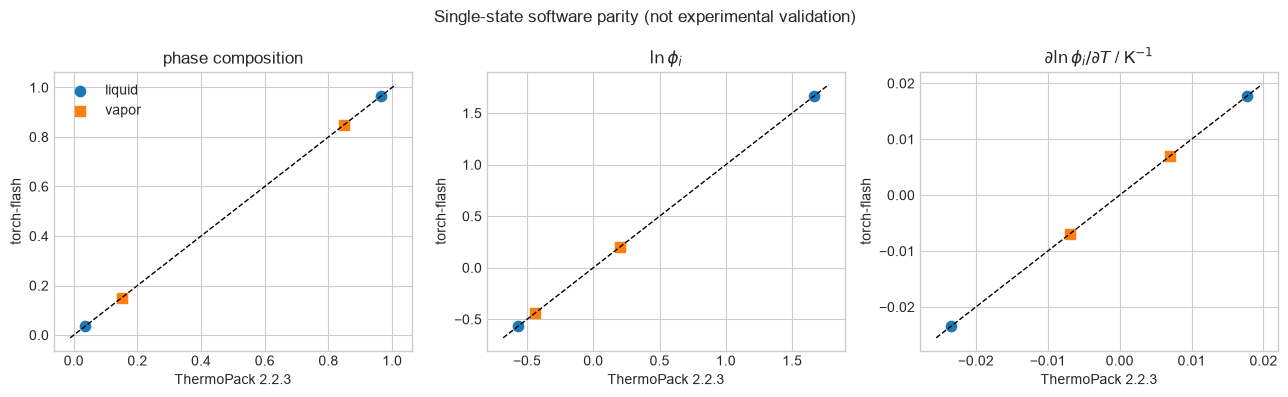

In [5]:
figure, axes = plt.subplots(1, 3, figsize=(13, 4))
parity_specs = [
    ("composition", "phase composition"),
    ("ln_phi", r"$\ln\phi_i$"),
    ("dlnphi_dT_1_per_K", r"$\partial\ln\phi_i/\partial T$ / K$^{-1}$"),
]
for axis, (quantity, title) in zip(axes, parity_specs, strict=True):
    x_reference = comparison[f"{quantity}_thermopack"].to_numpy()
    y_torch = comparison[f"{quantity}_torch"].to_numpy()
    lower = min(x_reference.min(), y_torch.min())
    upper = max(x_reference.max(), y_torch.max())
    padding = 0.05 * max(upper - lower, 1.0e-12)
    axis.plot(
        [lower - padding, upper + padding],
        [lower - padding, upper + padding],
        "k--",
        linewidth=1,
    )
    for phase_name, marker in (("liquid", "o"), ("vapor", "s")):
        selected = comparison["phase"] == phase_name
        axis.scatter(
            x_reference[selected],
            y_torch[selected],
            marker=marker,
            s=55,
            label=phase_name,
        )
    axis.set(
        xlabel="ThermoPack 2.2.3",
        ylabel="torch-flash",
        title=title,
    )
axes[0].legend()
figure.suptitle("Single-state software parity (not experimental validation)")
figure.tight_layout()
plt.show()

## Independent composition, TP/TV, and isofugacity checks

`log_fugacities` is the dimensionless
\(\ln(f_i/p^\circ)\), with \(p^\circ=1\) bar. The external notebook used
\(\ln(f_i/\mathrm{Pa})\); their difference is only the constant
\(\ln(p^\circ/\mathrm{Pa})\), so all derivatives are identical.

The independent Helmholtz route evaluates
\[
\ln\frac{f_i}{p^\circ}
=\ln\frac{n_iRT}{Vp^\circ}
+\left.\frac{\partial(A^R/RT)}{\partial n_i}\right|_{T,V,n_{j\ne i}}.
\]

In [6]:
independent_rows = []
consistency_rows = []
for phase_name, properties in (("liquid", liquid), ("vapor", vapor)):
    derivatives = derivative_objects[phase_name]
    tv_log_fugacity = log_fugacities_tv(
        model,
        temperature,
        properties.molar_volume,
        properties.composition,
    )
    for component_index, component_name in enumerate(("CO2", "N2")):
        independent_rows.append(
            {
                "phase": phase_name,
                "component": component_name,
                "dlnphi/dx_CO2": float(
                    derivatives.dlog_fugacity_coefficient_dindependent_composition[
                        component_index, 0
                    ]
                ),
                "dphi/dx_CO2": float(
                    derivatives.dfugacity_coefficient_dindependent_composition[
                        component_index, 0
                    ]
                ),
                "dlnf/dx_CO2": float(
                    derivatives.dlog_fugacity_dindependent_composition[
                        component_index, 0
                    ]
                ),
                "df/dx_CO2 / Pa": float(
                    derivatives.dfugacity_dindependent_composition[component_index, 0]
                ),
            }
        )
        consistency_rows.append(
            {
                "phase": phase_name,
                "component": component_name,
                "ln(f/p0) TP": float(properties.log_fugacities[component_index]),
                "ln(f/p0) TV": float(tv_log_fugacity[component_index]),
                "TP - TV": float(
                    properties.log_fugacities[component_index]
                    - tv_log_fugacity[component_index]
                ),
            }
        )

display(pd.DataFrame(independent_rows))
display(pd.DataFrame(consistency_rows))
isofugacity = pd.DataFrame(
    {
        "component": ["CO2", "N2"],
        "ln(f_liquid/p0)": liquid.log_fugacities.detach().numpy(),
        "ln(f_vapor/p0)": vapor.log_fugacities.detach().numpy(),
        "liquid - vapor": (liquid.log_fugacities - vapor.log_fugacities)
        .detach()
        .numpy(),
    }
)
display(isofugacity)

,phase,component,dlnphi/dx_CO2,dphi/dx_CO2,dlnf/dx_CO2,df/dx_CO2 / Pa
0,liquid,CO2,-0.185667,-0.105157,0.850755,2.789495e+06
1,liquid,N2,5.097772,26.930438,-23.358818,-2.601850e+07
2,vapor,CO2,-0.218019,-0.140423,0.960600,3.149661e+06
3,vapor,N2,1.220582,1.495179,-5.377931,-5.990274e+06


,phase,component,ln(f/p0) TP,ln(f/p0) TV,TP - TV
0,liquid,CO2,3.490077,3.490077,-5.329071e-15
1,liquid,N2,2.410418,2.410418,-5.329071e-15
2,vapor,CO2,3.490077,3.490077,4.440892e-16
3,vapor,N2,2.410418,2.410418,0.000000e+00


,component,ln(f_liquid/p0),ln(f_vapor/p0),liquid - vapor
0,CO2,3.490077,3.490077,1.776357e-15
1,N2,2.410418,2.410418,2.664535e-15


## Exact binary critical point and complete retrograde envelope

A temperature grid alone becomes singular at the maximum-temperature point.
`binary_critical_point` solves the binary conditions
\[
\frac{\partial^2(g/RT)}{\partial x_\mathrm{CO_2}^2}=0,\qquad
\frac{\partial^3(g/RT)}{\partial x_\mathrm{CO_2}^3}=0
\]
using PyTorch higher-order autodiff. The envelope uses temperature
continuation away from the singularity and fixed-\(\ln K_\mathrm{CO_2}\)
continuation through the critical point and toward the cricondentherm.

The low-temperature dew and bubble branches are also retained. Consequently
the plotted two-phase region is closed over the 130 K to cricondentherm
range—it is not the earlier narrow 205-250 K slice. Points remain in
continuation order across the retrograde turn.

This calculation is a sequence of tiny three- and four-variable systems.
GPU kernel-launch and host-synchronization costs dominate such scalar work;
the useful PyTorch acceleration here is a better continuation predictor
while retaining autodiff Jacobians. `phase_envelope` now extrapolates
\((\ln K,\ln P)\) from the previous two points, applies two
successive-substitution corrections, and falls back to the former robust
initializer only after a failed Newton solve. Fixed-\(\ln K\) continuation
uses the analogous secant predictor. The former algorithm remains available
through `accelerated=False`, allowing a same-run numerical and timing audit.

In [7]:
critical_started = time.perf_counter()
critical = binary_critical_point(model, z, tolerance=1.0e-10)
critical_seconds = time.perf_counter() - critical_started
assert critical.converged
critical_reference = {
    "temperature_K": 296.73751605547142,
    "pressure_Pa": 8_769_014.866603531,
    "molar_volume_m3_per_mol": 9.825174252413657e-05,
}
critical_table = pd.DataFrame(
    {
        "quantity": ["temperature / K", "pressure / MPa", "volume / m3 mol-1"],
        "torch-flash": [
            float(critical.temperature),
            float(critical.pressure / 1.0e6),
            float(critical.molar_volume),
        ],
        "ThermoPack 2.2.3": [
            critical_reference["temperature_K"],
            critical_reference["pressure_Pa"] / 1.0e6,
            critical_reference["molar_volume_m3_per_mol"],
        ],
    }
)
critical_table["relative error"] = (
    critical_table["torch-flash"] - critical_table["ThermoPack 2.2.3"]
).abs() / critical_table["ThermoPack 2.2.3"].abs()
display(critical_table)
print(
    f"critical solve: {critical_seconds:.3f} s, "
    f"{critical.iterations} Newton iterations, "
    f"residual={float(critical.residual_norm):.3e}"
)

,quantity,torch-flash,ThermoPack 2.2.3,relative error
0,temperature / K,296.737516,296.737516,1.000446e-09
1,pressure / MPa,8.769014,8.769015,8.685911e-08
2,volume / m3 mol-1,0.000098,0.000098,2.879786e-07


critical solve: 2.015 s, 15 Newton iterations, residual=2.617e-11


In [8]:
bubble_temperatures = torch.linspace(130.0, 296.4, 170)
dew_temperatures = torch.cat(
    (
        bubble_temperatures,
        torch.linspace(296.45, 297.18, 30),
    )
)


def trace_complete_envelope(accelerated):
    """Trace all physical segments and return the elapsed solver time."""
    started = time.perf_counter()
    bubble = phase_envelope(
        model,
        bubble_temperatures,
        z,
        kinds=("bubble",),
        accelerated=accelerated,
    )["bubble"]
    dew = phase_envelope(
        model,
        dew_temperatures,
        z,
        kinds=("dew",),
        accelerated=accelerated,
    )["dew"]
    bubble = tuple(
        point
        for point in bubble
        if point.converged
        and float(torch.max(torch.abs(torch.log(point.k_values)))) > 1.0e-4
    )
    dew = tuple(
        point
        for point in dew
        if point.converged
        and float(torch.max(torch.abs(torch.log(point.k_values)))) > 1.0e-4
    )
    targets = torch.linspace(
        torch.log(bubble[-1].k_values[0]),
        0.022,
        100,
    )[1:]
    fixed_log_k = continue_saturation_branch(
        model,
        z,
        bubble[-1],
        targets,
        accelerated=accelerated,
    )
    assert all(point.converged for point in fixed_log_k)
    return bubble, dew, fixed_log_k, time.perf_counter() - started


bubble_base, dew_base, retrograde, envelope_seconds = trace_complete_envelope(
    accelerated=True
)
legacy_bubble, legacy_dew, legacy_retrograde, legacy_envelope_seconds = (
    trace_complete_envelope(accelerated=False)
)

continuation_parity = []
for branch_name, accelerated_points, legacy_points in (
    ("bubble", bubble_base, legacy_bubble),
    ("dew", dew_base, legacy_dew),
    ("fixed-logK", retrograde, legacy_retrograde),
):
    accelerated_temperature = torch.stack(
        tuple(point.temperature for point in accelerated_points)
    )
    legacy_temperature = torch.stack(
        tuple(point.temperature for point in legacy_points)
    )
    accelerated_pressure = torch.stack(
        tuple(point.pressure for point in accelerated_points)
    )
    legacy_pressure = torch.stack(tuple(point.pressure for point in legacy_points))
    maximum_temperature_difference = float(
        torch.max(torch.abs(accelerated_temperature - legacy_temperature))
    )
    maximum_pressure_difference = float(
        torch.max(torch.abs(accelerated_pressure - legacy_pressure))
    )
    assert maximum_temperature_difference < 2.0e-3
    assert maximum_pressure_difference < 300.0
    continuation_parity.append(
        {
            "branch": branch_name,
            "maximum |delta T| / K": maximum_temperature_difference,
            "maximum |delta P| / Pa": maximum_pressure_difference,
        }
    )
display(pd.DataFrame(continuation_parity))

retrograde_temperatures = torch.stack(tuple(point.temperature for point in retrograde))
cricondentherm_index = int(torch.argmax(retrograde_temperatures))
retrograde_to_maximum = retrograde[: cricondentherm_index + 1]
cricondentherm = retrograde_to_maximum[-1]

# Assemble one closed curve: low-T bubble -> high-T retrograde maximum ->
# reversed low-pressure dew -> low-T closure.
closed_envelope = bubble_base + retrograde_to_maximum + tuple(reversed(dew_base))

envelope_records = pd.DataFrame(
    {
        "temperature_K": [float(point.temperature) for point in closed_envelope],
        "pressure_bar": [float(point.pressure / 1.0e5) for point in closed_envelope],
        "segment": (
            ["bubble"] * len(bubble_base)
            + ["fixed-logK"] * len(retrograde_to_maximum)
            + ["dew"] * len(dew_base)
        ),
    }
)
external_envelope = pd.read_csv(DATA_DIR / "thermopack_2_2_3_pr78_co2_n2_envelope.csv")
external_envelope["pressure_bar"] = external_envelope["pressure_Pa"] / 1.0e5

external_maximum_index = int(external_envelope["temperature_K"].idxmax())
external_dew = external_envelope.iloc[: external_maximum_index + 1].copy()
external_high = external_envelope.iloc[external_maximum_index + 1 :].copy()
parity_dew_temperature = np.array([float(point.temperature) for point in dew_base])
parity_dew_pressure = np.array([float(point.pressure) for point in dew_base])
high_temperature = np.r_[
    [float(point.temperature) for point in bubble_base],
    [float(point.temperature) for point in retrograde_to_maximum],
]
high_pressure = np.r_[
    [float(point.pressure) for point in bubble_base],
    [float(point.pressure) for point in retrograde_to_maximum],
]
external_dew["torch_pressure_bar"] = (
    np.interp(
        external_dew["temperature_K"],
        parity_dew_temperature,
        parity_dew_pressure,
    )
    / 1.0e5
)
external_high["torch_pressure_bar"] = (
    np.interp(
        external_high["temperature_K"],
        high_temperature,
        high_pressure,
    )
    / 1.0e5
)
envelope_parity = pd.concat(
    [
        external_dew.assign(branch="low-pressure/dew"),
        external_high.assign(branch="high-pressure/bubble"),
    ],
    ignore_index=True,
)
envelope_parity["absolute_pressure_error_bar"] = (
    envelope_parity["torch_pressure_bar"] - envelope_parity["pressure_bar"]
).abs()
envelope_parity["relative_pressure_error_percent"] = (
    100.0
    * envelope_parity["absolute_pressure_error_bar"]
    / envelope_parity["pressure_bar"]
)
display(
    pd.DataFrame(
        {
            "metric": [
                "mean absolute relative pressure error / %",
                "maximum relative pressure error / %",
                "maximum absolute pressure error / bar",
            ],
            "value": [
                envelope_parity["relative_pressure_error_percent"].mean(),
                envelope_parity["relative_pressure_error_percent"].max(),
                envelope_parity["absolute_pressure_error_bar"].max(),
            ],
        }
    )
)

cricondentherm_table = pd.DataFrame(
    {
        "source": ["torch-flash", "ThermoPack 2.2.3 sampled maximum"],
        "temperature / K": [
            float(cricondentherm.temperature),
            external_envelope["temperature_K"].max(),
        ],
        "pressure / bar": [
            float(cricondentherm.pressure / 1.0e5),
            external_envelope.loc[
                external_envelope["temperature_K"].idxmax(), "pressure_bar"
            ],
        ],
    }
)
display(cricondentherm_table)
historical_envelope_seconds = 26.458
envelope_timing = pd.DataFrame(
    {
        "run": [
            "previous executed notebook",
            "same-run legacy mode",
            "accelerated continuation",
        ],
        "seconds": [
            historical_envelope_seconds,
            legacy_envelope_seconds,
            envelope_seconds,
        ],
        "speedup versus same-run legacy": [
            np.nan,
            1.0,
            legacy_envelope_seconds / envelope_seconds,
        ],
    }
)
display(envelope_timing)
print(
    f"complete envelope calculation: {envelope_seconds:.3f} s "
    f"for {len(bubble_base) + len(dew_base) + len(retrograde)} solved points; "
    f"{legacy_envelope_seconds / envelope_seconds:.2f}x same-run speedup"
)

,branch,maximum |delta T| / K,maximum |delta P| / Pa
0,bubble,0.000000,0.111707
1,dew,0.000000,0.195177
2,fixed-logK,0.001329,245.067117


,metric,value
0,mean absolute relative pressure error / %,0.015279
1,maximum relative pressure error / %,0.245453
2,maximum absolute pressure error / bar,0.208814


,source,temperature / K,pressure / bar
0,torch-flash,297.194200,85.425988
1,ThermoPack 2.2.3 sampled maximum,297.188842,85.072751


,run,seconds,speedup versus same-run legacy
0,previous executed notebook,26.458000,NaN
1,same-run legacy mode,12.044622,1.000000
2,accelerated continuation,4.713043,2.555593


complete envelope calculation: 4.713 s for 469 solved points; 2.56x same-run speedup


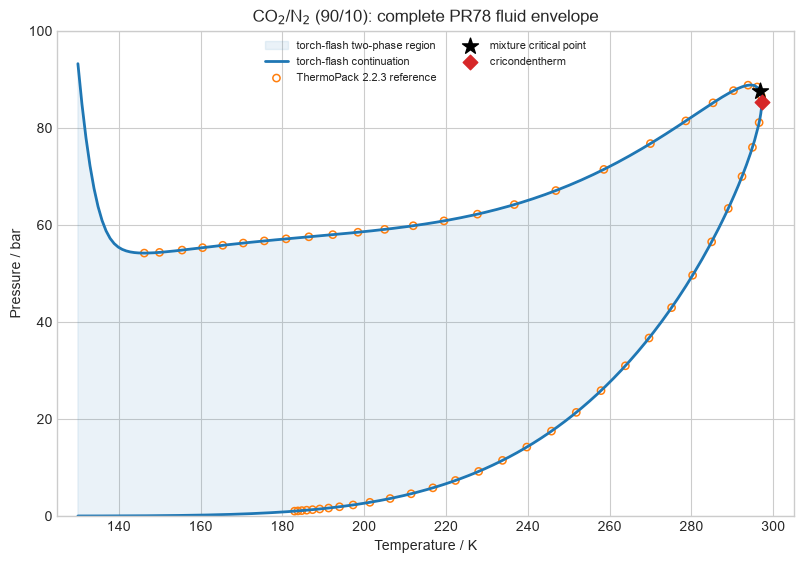

In [9]:
figure, axis = plt.subplots(figsize=(9.5, 6.3))
axis.fill(
    envelope_records["temperature_K"],
    envelope_records["pressure_bar"],
    color="tab:blue",
    alpha=0.09,
    label="torch-flash two-phase region",
)
axis.plot(
    envelope_records["temperature_K"],
    envelope_records["pressure_bar"],
    color="tab:blue",
    linewidth=2.0,
    label="torch-flash continuation",
)
axis.scatter(
    external_envelope["temperature_K"],
    external_envelope["pressure_bar"],
    facecolors="none",
    edgecolors="tab:orange",
    s=27,
    linewidth=1.1,
    label="ThermoPack 2.2.3 reference",
)
axis.scatter(
    [float(critical.temperature)],
    [float(critical.pressure / 1.0e5)],
    marker="*",
    s=145,
    color="black",
    label="mixture critical point",
    zorder=5,
)
axis.scatter(
    [float(cricondentherm.temperature)],
    [float(cricondentherm.pressure / 1.0e5)],
    marker="D",
    s=55,
    color="tab:red",
    label="cricondentherm",
    zorder=5,
)
axis.set(
    xlim=(125.0, 305.0),
    ylim=(0.0, 100.0),
    xlabel="Temperature / K",
    ylabel="Pressure / bar",
    title=r"CO$_2$/N$_2$ (90/10): complete PR78 fluid envelope",
)
axis.legend(fontsize=8, ncol=2)
plt.show()

## The 100 by 100 synthetic derivative grid

Running 10,000 independent stability minimizations would obscure the
PyTorch advantage. For a fixed overall composition, the already-computed
dew/bubble branches identify the two-phase cells. Those cells are solved in
one tensor batch with `batched_two_phase_flash`; the remaining homogeneous
cells are evaluated directly. A scalar flash is retained only as an explicit
fallback for a batched state that fails its convergence/physical-fraction
gate.

The property convention matches the external study: in a two-phase cell,
derivatives are evaluated in the equilibrium **liquid** phase; in a
homogeneous cell they are evaluated at the overall composition and the
minimum-Gibbs cubic root.

In [10]:
temperature_axis = np.linspace(130.0, 300.0, 100)
pressure_axis_bar = np.linspace(1.0, 100.0, 100)
temperature_grid, pressure_grid_bar = np.meshgrid(
    temperature_axis,
    pressure_axis_bar,
    indexing="ij",
)
temperature_flat = torch.tensor(temperature_grid.ravel())
pressure_flat = torch.tensor(pressure_grid_bar.ravel() * 1.0e5)


def point_arrays(points):
    return (
        np.array([float(point.temperature) for point in points]),
        np.array([float(point.pressure) for point in points]),
        np.stack([torch.log(point.k_values).detach().numpy() for point in points]),
    )


bubble_temperature, bubble_pressure, bubble_log_k = point_arrays(bubble_base)
retro_temperature, retro_pressure, retro_log_k = point_arrays(retrograde_to_maximum)
dew_temperature, dew_pressure, dew_log_k = point_arrays(dew_base)


def interpolate_branch(temperature_values, branch_t, branch_p, branch_log_k):
    order = np.argsort(branch_t)
    sorted_t = branch_t[order]
    pressure_values = np.interp(temperature_values, sorted_t, branch_p[order])
    log_k_values = np.column_stack(
        [
            np.interp(
                temperature_values,
                sorted_t,
                branch_log_k[order, component],
            )
            for component in range(branch_log_k.shape[1])
        ]
    )
    return pressure_values, log_k_values


grid_t_numpy = temperature_flat.numpy()
dew_pressure_grid, dew_log_k_grid = interpolate_branch(
    grid_t_numpy,
    dew_temperature,
    dew_pressure,
    dew_log_k,
)
bubble_pressure_grid = np.empty_like(grid_t_numpy)
bubble_log_k_grid = np.empty((grid_t_numpy.size, 2))
ordinary = grid_t_numpy <= bubble_temperature.max()
bubble_pressure_grid[ordinary], bubble_log_k_grid[ordinary] = interpolate_branch(
    grid_t_numpy[ordinary],
    bubble_temperature,
    bubble_pressure,
    bubble_log_k,
)
bubble_pressure_grid[~ordinary], bubble_log_k_grid[~ordinary] = interpolate_branch(
    grid_t_numpy[~ordinary],
    retro_temperature,
    retro_pressure,
    retro_log_k,
)

within_temperature = grid_t_numpy <= float(cricondentherm.temperature)
two_phase_mask_numpy = (
    within_temperature
    & (pressure_flat.numpy() >= dew_pressure_grid)
    & (pressure_flat.numpy() <= bubble_pressure_grid)
)
two_phase_indices = np.flatnonzero(two_phase_mask_numpy)
single_phase_indices = np.flatnonzero(~two_phase_mask_numpy)

In [11]:
flash_started = time.perf_counter()
selected_pressure = pressure_flat[two_phase_indices]
log_pressure_fraction = (
    torch.log(selected_pressure)
    - torch.log(torch.tensor(dew_pressure_grid[two_phase_indices]))
) / (
    torch.log(torch.tensor(bubble_pressure_grid[two_phase_indices]))
    - torch.log(torch.tensor(dew_pressure_grid[two_phase_indices]))
)
initial_log_k = (1.0 - log_pressure_fraction[:, None]) * torch.tensor(
    dew_log_k_grid[two_phase_indices]
) + log_pressure_fraction[:, None] * torch.tensor(bubble_log_k_grid[two_phase_indices])
batched_flash = batched_two_phase_flash(
    model,
    ChemicalState(
        temperature_flat[two_phase_indices],
        selected_pressure,
        z,
    ),
    initial_k_values=torch.exp(initial_log_k),
    tolerance=2.0e-8,
)

liquid_composition = batched_flash.liquid_composition.detach().clone()
vapor_composition = batched_flash.vapor_composition.detach().clone()
vapor_fraction = batched_flash.vapor_fraction.detach().clone()
fallback_positions = torch.where(~batched_flash.converged)[0]
fallback_failures = []
for position in fallback_positions.tolist():
    scalar = two_phase_flash(
        model,
        ChemicalState(
            temperature_flat[two_phase_indices[position]],
            selected_pressure[position],
            z,
        ),
        initial_k_values=batched_flash.k_values[position],
        check_stability=False,
        tolerance=1.0e-10,
        max_iterations=150,
    )
    if scalar.converged:
        liquid_composition[position] = scalar.phases[0].composition
        vapor_composition[position] = scalar.phases[1].composition
        vapor_fraction[position] = scalar.phase_fractions[1]
    else:
        fallback_failures.append(position)
flash_seconds = time.perf_counter() - flash_started
assert not fallback_failures

print(
    f"{len(two_phase_indices):,} two-phase cells: "
    f"batched + {len(fallback_positions)} scalar fallbacks in "
    f"{flash_seconds:.3f} s"
)
print(
    "maximum accepted batched log-fugacity residual = "
    f"{float(batched_flash.residual_norm[batched_flash.converged].max()):.3e}"
)

4,870 two-phase cells: batched + 3 scalar fallbacks in 0.443 s
maximum accepted batched log-fugacity residual = 1.984e-08


In [12]:
# Assemble equilibrium split columns.
n_states = temperature_flat.numel()
x_equilibrium = z.expand(n_states, -1).clone()
y_equilibrium = z.expand(n_states, -1).clone()
beta_vapor = torch.zeros(n_states)
beta_liquid = torch.ones(n_states)
x_equilibrium[two_phase_indices] = liquid_composition
y_equilibrium[two_phase_indices] = vapor_composition
beta_vapor[two_phase_indices] = vapor_fraction
beta_liquid[two_phase_indices] = 1.0 - vapor_fraction

# Envelope topology is the unambiguous classifier away from its critical
# closure: below dew is vapor, between branches is two-phase, and above bubble
# is liquid. This avoids applying a one-state V/b heuristic in the
# near-critical region where liquid and vapor properties become continuous.
single_is_liquid_numpy = within_temperature[single_phase_indices] & (
    pressure_flat.numpy()[single_phase_indices]
    > bubble_pressure_grid[single_phase_indices]
)
single_is_liquid = torch.tensor(single_is_liquid_numpy)
beta_liquid[single_phase_indices] = single_is_liquid.to(torch.float64)
beta_vapor[single_phase_indices] = (~single_is_liquid).to(torch.float64)

phase_kind = np.full(n_states, "Single-phase (V)", dtype=object)
phase_id = np.full(n_states, 2, dtype=int)
liquid_global = np.zeros(n_states, dtype=bool)
liquid_global[single_phase_indices] = single_is_liquid.numpy()
phase_kind[liquid_global] = "Single-phase (L)"
phase_id[liquid_global] = 1
supercritical = (
    (grid_t_numpy > float(critical.temperature))
    & (pressure_flat.numpy() > float(critical.pressure))
    & ~two_phase_mask_numpy
)
phase_kind[supercritical] = "Single-phase (supercritical)"
phase_id[supercritical] = 4
phase_kind[two_phase_indices] = "Two-phase (LV)"
phase_id[two_phase_indices] = 0

### Batched autodiff fields

Summing the component response over a batch before calling
`torch.autograd.grad` returns the diagonal statewise derivatives because
the states are independent. This avoids building a dense
\(10{,}000\times10{,}000\) Jacobian.

In [13]:
def evaluate_co2_fields(indices, compositions, phase):
    current_temperature = temperature_flat[indices].detach().requires_grad_(True)
    current_pressure = pressure_flat[indices].detach().requires_grad_(True)
    current_moles = compositions.detach().requires_grad_(True)
    current_composition = current_moles / current_moles.sum(dim=-1, keepdim=True)
    log_phi = model.log_fugacity_coefficients(
        current_temperature,
        current_pressure,
        current_composition,
        phase,
    )
    log_phi_co2 = log_phi[:, 0]
    phi_co2 = torch.exp(log_phi_co2)
    log_fugacity_co2 = (
        torch.log(current_composition[:, 0]) + log_phi_co2 + torch.log(current_pressure)
    )
    fugacity_co2 = torch.exp(log_fugacity_co2)

    dlogphi_dt = torch.autograd.grad(
        log_phi_co2.sum(),
        current_temperature,
        retain_graph=True,
    )[0]
    dlogphi_dp = torch.autograd.grad(
        log_phi_co2.sum(),
        current_pressure,
        retain_graph=True,
    )[0]
    dlogphi_dn = torch.autograd.grad(
        log_phi_co2.sum(),
        current_moles,
        retain_graph=True,
    )[0][:, 0]
    dlogf_dn = torch.autograd.grad(
        log_fugacity_co2.sum(),
        current_moles,
    )[
        0
    ][:, 0]
    return {
        "lnphi_CO2": log_phi_co2.detach(),
        "phi_CO2": phi_co2.detach(),
        "dlnphi_CO2_dT_1_per_K": dlogphi_dt.detach(),
        "dlnphi_CO2_dP_1_per_Pa": dlogphi_dp.detach(),
        "dlnphi_CO2_dn_CO2_1_per_mol": dlogphi_dn.detach(),
        "dphi_CO2_dT_1_per_K": (phi_co2 * dlogphi_dt).detach(),
        "dphi_CO2_dP_1_per_Pa": (phi_co2 * dlogphi_dp).detach(),
        "dphi_CO2_dn_CO2_1_per_mol": (phi_co2 * dlogphi_dn).detach(),
        "f_CO2_Pa": fugacity_co2.detach(),
        "df_CO2_dT_Pa_per_K": (fugacity_co2 * dlogphi_dt).detach(),
        "df_CO2_dP_Pa_per_Pa": (
            fugacity_co2 * (dlogphi_dp + 1.0 / current_pressure)
        ).detach(),
        "df_CO2_dn_CO2_Pa_per_mol": (fugacity_co2 * dlogf_dn).detach(),
    }


derivative_started = time.perf_counter()
field_names = [
    "lnphi_CO2",
    "phi_CO2",
    "dlnphi_CO2_dT_1_per_K",
    "dlnphi_CO2_dP_1_per_Pa",
    "dlnphi_CO2_dn_CO2_1_per_mol",
    "dphi_CO2_dT_1_per_K",
    "dphi_CO2_dP_1_per_Pa",
    "dphi_CO2_dn_CO2_1_per_mol",
    "f_CO2_Pa",
    "df_CO2_dT_Pa_per_K",
    "df_CO2_dP_Pa_per_Pa",
    "df_CO2_dn_CO2_Pa_per_mol",
]
fields = {name: torch.empty(n_states) for name in field_names}
two_phase_fields = evaluate_co2_fields(
    two_phase_indices,
    liquid_composition,
    "liquid",
)
single_phase_fields = evaluate_co2_fields(
    single_phase_indices,
    z.expand(len(single_phase_indices), -1),
    "stable",
)
for name in field_names:
    fields[name][two_phase_indices] = two_phase_fields[name]
    fields[name][single_phase_indices] = single_phase_fields[name]
derivative_seconds = time.perf_counter() - derivative_started
print(f"all 10,000 homogeneous derivative evaluations: {derivative_seconds:.3f} s")

all 10,000 homogeneous derivative evaluations: 0.024 s


In [14]:
grid_results = pd.DataFrame(
    {
        "P": pressure_flat.numpy() / 1.0e5,
        "T": temperature_flat.numpy(),
        "x_CO2": x_equilibrium[:, 0].numpy(),
        "y_CO2": y_equilibrium[:, 0].numpy(),
        "x_N2": x_equilibrium[:, 1].numpy(),
        "y_N2": y_equilibrium[:, 1].numpy(),
        "betaL": beta_liquid.numpy(),
        "betaV": beta_vapor.numpy(),
        **{name: value.numpy() for name, value in fields.items()},
        "phase_id": phase_id,
        "phase_kind": phase_kind,
    }
)
grid_results.to_csv(OUTPUT_CSV, index=False)
print(f"exported {len(grid_results):,} rows to {OUTPUT_CSV.relative_to(ROOT)}")
display(grid_results.head())
display(
    grid_results.groupby("phase_kind", sort=False)
    .size()
    .rename("grid cells")
    .to_frame()
)

exported 10,000 rows to notebooks/verification/synthetic_co2_data_PR78_with_derivatives.csv


,P,T,x_CO2,y_CO2,x_N2,y_N2,betaL,betaV,lnphi_CO2,phi_CO2,...,dlnphi_CO2_dn_CO2_1_per_mol,dphi_CO2_dT_1_per_K,dphi_CO2_dP_1_per_Pa,dphi_CO2_dn_CO2_1_per_mol,f_CO2_Pa,df_CO2_dT_Pa_per_K,df_CO2_dP_Pa_per_Pa,df_CO2_dn_CO2_Pa_per_mol,phase_id,phase_kind
0,1.0,130.0,0.997346,0.006863,0.002654,0.993137,0.901719,0.098281,-5.017326,0.006622,...,-0.000031,0.000902,-6.602654e-08,-2.042415e-07,660.463419,89.927077,0.00002,1.737309,0,Two-phase (LV)
1,2.0,130.0,0.994682,0.003568,0.005318,0.996432,0.904469,0.095531,-5.707474,0.003321,...,-0.000124,0.000452,-1.650719e-08,-4.116264e-07,660.678353,89.943594,0.00002,3.450259,0,Two-phase (LV)
2,3.0,130.0,0.992028,0.002475,0.007972,0.997525,0.907001,0.092999,-6.109908,0.002221,...,-0.000279,0.000302,-7.336937e-09,-6.193252e-07,660.915016,89.962906,0.00002,5.127021,0,Two-phase (LV)
3,4.0,130.0,0.989383,0.001933,0.010617,0.998067,0.909481,0.090519,-6.394530,0.001671,...,-0.000495,0.000227,-4.127347e-09,-8.272110e-07,661.173852,89.985073,0.00002,6.767445,0,Two-phase (LV)
4,5.0,130.0,0.986750,0.001611,0.013250,0.998389,0.911942,0.088058,-6.614582,0.001341,...,-0.000772,0.000182,-2.641763e-09,-1.035149e-06,661.455318,90.010158,0.00002,8.371388,0,Two-phase (LV)


,grid cells
phase_kind,
Two-phase (LV),4870
Single-phase (L),3451
Single-phase (V),1653
Single-phase (supercritical),26


## Phase map

`supercritical` is retained here only to reproduce the external diagram's
category. It is a diagram-level label based on \(T>T_c\) and \(P>P_c\), not
a separate thermodynamic phase. The package's physical phase identification
remains liquid/vapor/unknown and is independent of this plotting label.

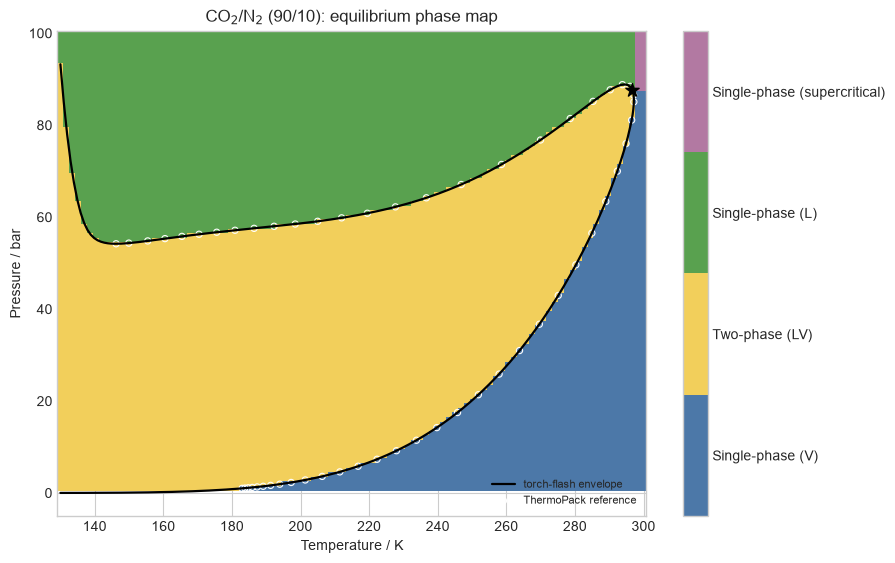

In [15]:
phase_order = [
    "Single-phase (V)",
    "Two-phase (LV)",
    "Single-phase (L)",
    "Single-phase (supercritical)",
]
phase_code = {label: index for index, label in enumerate(phase_order)}
phase_grid = np.vectorize(phase_code.get)(
    grid_results["phase_kind"].to_numpy()
).reshape(100, 100)
phase_colors = ListedColormap(["#4C78A8", "#F2CF5B", "#59A14F", "#B279A2"])
phase_norm = BoundaryNorm(
    np.arange(-0.5, len(phase_order) + 0.5),
    len(phase_order),
)

figure, axis = plt.subplots(figsize=(9.5, 6.3))
mesh = axis.pcolormesh(
    temperature_axis,
    pressure_axis_bar,
    phase_grid.T,
    cmap=phase_colors,
    norm=phase_norm,
    shading="nearest",
)
axis.plot(
    envelope_records["temperature_K"],
    envelope_records["pressure_bar"],
    "k-",
    linewidth=1.6,
    label="torch-flash envelope",
)
axis.scatter(
    external_envelope["temperature_K"],
    external_envelope["pressure_bar"],
    facecolors="none",
    edgecolors="white",
    linewidth=0.8,
    s=20,
    label="ThermoPack reference",
)
axis.scatter(
    [float(critical.temperature)],
    [float(critical.pressure / 1.0e5)],
    marker="*",
    color="black",
    s=100,
    zorder=5,
)
colorbar = figure.colorbar(mesh, ax=axis, ticks=range(len(phase_order)))
colorbar.ax.set_yticklabels(phase_order)
axis.set(
    xlabel="Temperature / K",
    ylabel="Pressure / bar",
    title=r"CO$_2$/N$_2$ (90/10): equilibrium phase map",
)
axis.legend(loc="lower right", fontsize=8)
plt.show()

## CO₂ fugacity and fugacity-coefficient fields

Every panel uses Matplotlib's default linear color normalization, matching the
original ThermoPack study so the spatial patterns and color contrasts can be
compared directly. The envelope is overlaid on every field so discontinuous
changes can be interpreted against the selected liquid-property convention
inside the two-phase region.

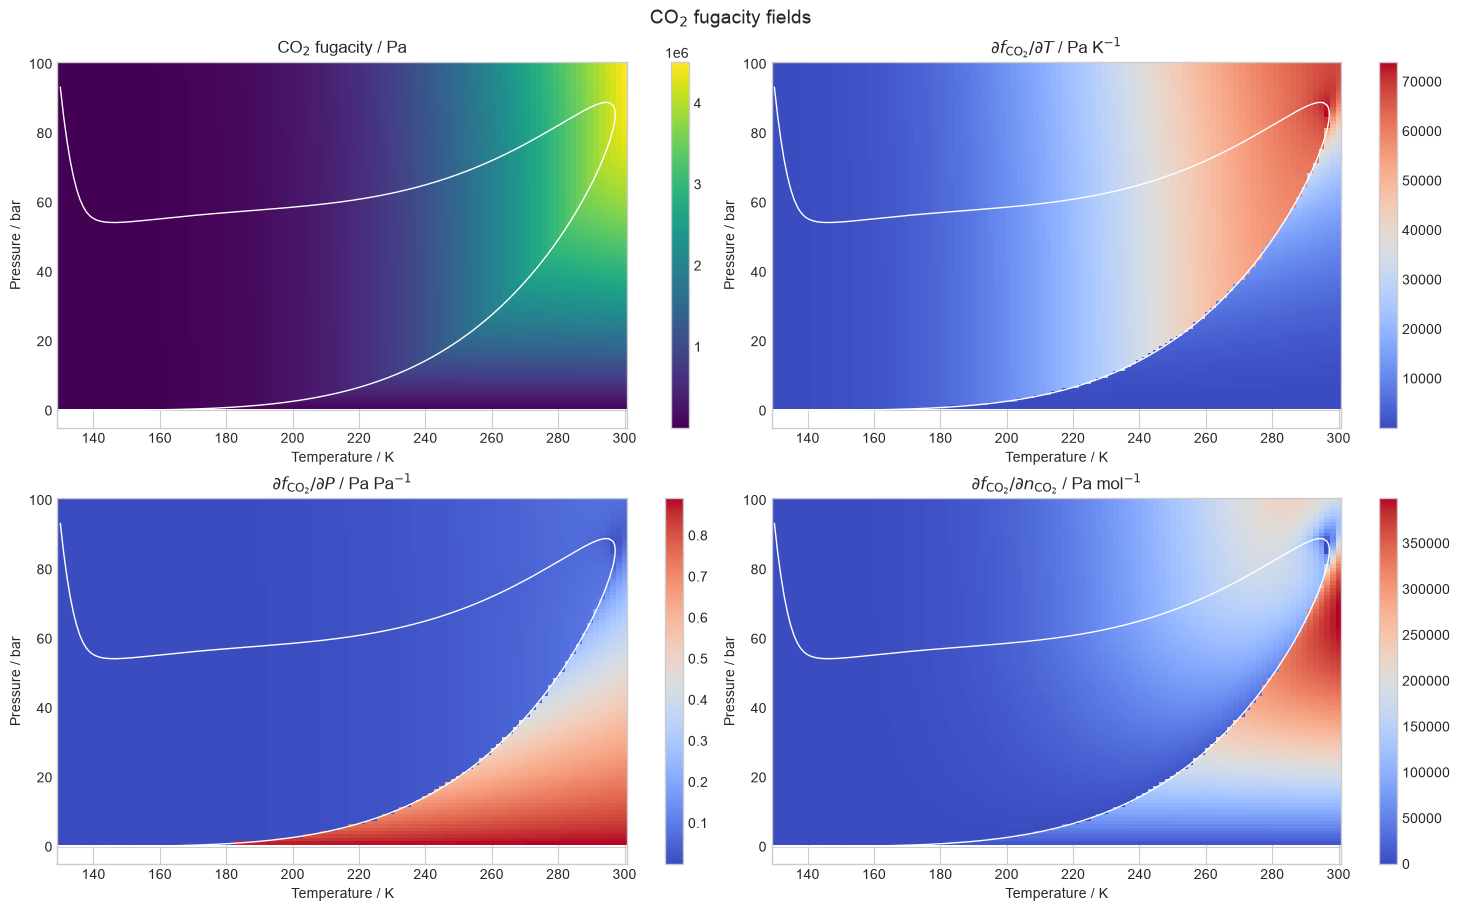

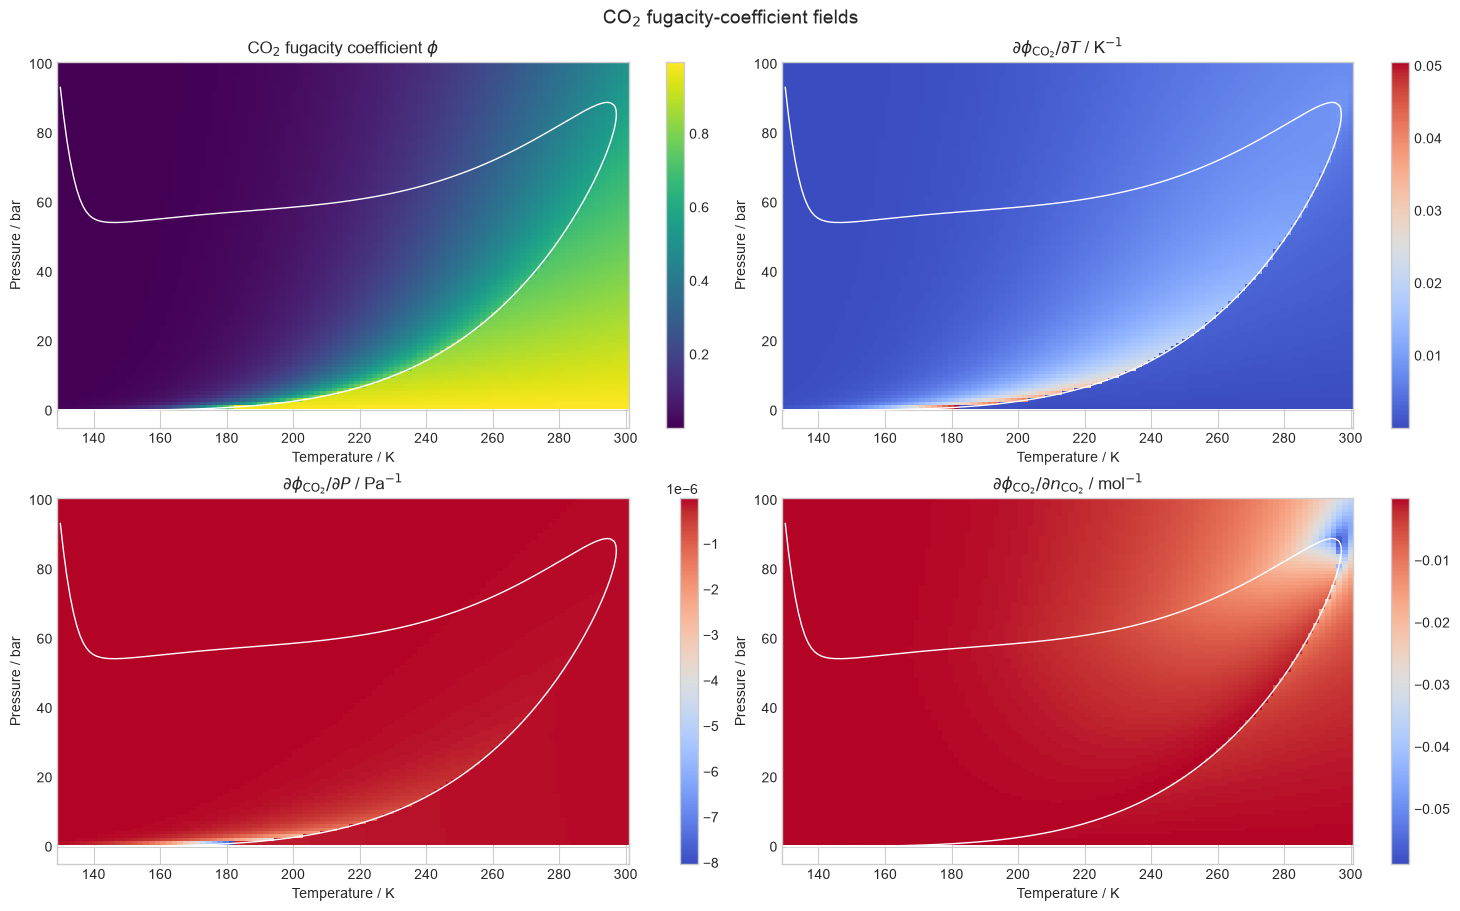

In [16]:
def plot_grid_fields(specifications, title):
    figure, axes = plt.subplots(2, 2, figsize=(14.5, 9), constrained_layout=True)
    for axis, (column, label, cmap) in zip(
        axes.ravel(),
        specifications,
        strict=True,
    ):
        values = grid_results[column].to_numpy().reshape(100, 100)
        image = axis.pcolormesh(
            temperature_axis,
            pressure_axis_bar,
            values.T,
            shading="nearest",
            cmap=cmap,
        )
        axis.plot(
            envelope_records["temperature_K"],
            envelope_records["pressure_bar"],
            color="white",
            linewidth=1.0,
        )
        axis.set(
            xlabel="Temperature / K",
            ylabel="Pressure / bar",
            title=label,
        )
        figure.colorbar(image, ax=axis)
    figure.suptitle(title, fontsize=14)
    plt.show()


fugacity_field_specs = [
    ("f_CO2_Pa", r"CO$_2$ fugacity / Pa", "viridis"),
    (
        "df_CO2_dT_Pa_per_K",
        r"$\partial f_{\rm CO_2}/\partial T$ / Pa K$^{-1}$",
        "coolwarm",
    ),
    (
        "df_CO2_dP_Pa_per_Pa",
        r"$\partial f_{\rm CO_2}/\partial P$ / Pa Pa$^{-1}$",
        "coolwarm",
    ),
    (
        "df_CO2_dn_CO2_Pa_per_mol",
        r"$\partial f_{\rm CO_2}/\partial n_{\rm CO_2}$ / Pa mol$^{-1}$",
        "coolwarm",
    ),
]
phi_field_specs = [
    ("phi_CO2", r"CO$_2$ fugacity coefficient $\phi$", "viridis"),
    (
        "dphi_CO2_dT_1_per_K",
        r"$\partial\phi_{\rm CO_2}/\partial T$ / K$^{-1}$",
        "coolwarm",
    ),
    (
        "dphi_CO2_dP_1_per_Pa",
        r"$\partial\phi_{\rm CO_2}/\partial P$ / Pa$^{-1}$",
        "coolwarm",
    ),
    (
        "dphi_CO2_dn_CO2_1_per_mol",
        r"$\partial\phi_{\rm CO_2}/\partial n_{\rm CO_2}$ / mol$^{-1}$",
        "coolwarm",
    ),
]
plot_grid_fields(fugacity_field_specs, r"CO$_2$ fugacity fields")
plot_grid_fields(phi_field_specs, r"CO$_2$ fugacity-coefficient fields")

## Conclusions and limitations

- With the exact ThermoPack parameter set, the flash, translated phase
  volumes, fugacity coefficients, and first derivatives agree to numerical
  precision. This isolates the algebra from ordinary database differences.
- TP and TV fugacities agree independently, confirming that volume
  translation is applied consistently to volume, residual Helmholtz energy,
  and \(\ln\phi_i\).
- The native higher-order-autodiff critical solve reproduces the independent
  critical state. Fixed-log-K continuation reaches the higher-temperature
  cricondentherm and prevents premature collapse to \(K_i=1\).
- The secant-predicted envelope differs from the legacy trace by at most
  0.001329 K and 245.1 Pa in this execution, close to the ill-conditioned
  critical region. The timing table reports both modes on the same run and
  retains the previous notebook's 26.458 s result as historical context;
  timings remain hardware- and load-specific.
- The 10,000-row CSV reproduces the external study's columns and two-phase
  liquid-property convention. Batched flash and batched autodiff keep the
  calculation practical without hiding convergence failures.
- This is verification against another PR78 implementation. It does not
  establish CO₂/N₂ model accuracy against experiment, and the phase map
  should not be extrapolated beyond the plotted range without a separate
  stability and validity assessment.